✅ CSV salvato in: subject5_results.csv
✅ Grafico salvato in: subject5_plot.png


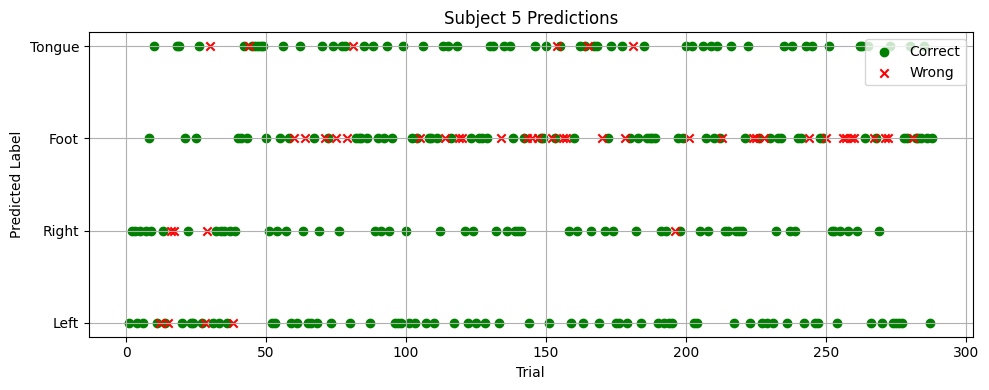

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def analyze_preds(data_dir, subject,
                  true_fname, pred_fname,
                  output_csv, output_png):
    # 1) Costruisci i path completi
    true_path = os.path.join(data_dir, true_fname)
    pred_path = os.path.join(data_dir, pred_fname)

    # 2) Carica i .npy
    y_true = np.load(true_path)
    y_pred = np.load(pred_path)
    if y_true.shape != y_pred.shape:
        raise ValueError(f"Shape mismatch: true {y_true.shape} vs pred {y_pred.shape}")

    n_trials = y_true.shape[0]
    # 3) Crea DataFrame
    df = pd.DataFrame({
        'trial':      np.arange(1, n_trials+1),
        'true_label': y_true,
        'pred_label': y_pred
    })

    # 4) Salva CSV
    os.makedirs(os.path.dirname(output_csv) or '.', exist_ok=True)
    df.to_csv(output_csv, index=False)
    print(f"✅ CSV salvato in: {output_csv}")

    # 5) Plot predizioni colorate
    correct = df['true_label'] == df['pred_label']
    trials  = df['trial']
    preds   = df['pred_label']

    plt.figure(figsize=(10,4))
    plt.scatter(trials[correct],   preds[correct],
                c='green', marker='o', label='Correct')
    plt.scatter(trials[~correct],  preds[~correct],
                c='red',   marker='x', label='Wrong')
    plt.title(f"Subject {subject} Predictions")
    plt.xlabel('Trial')
    plt.ylabel('Predicted Label')
    # Se vuoi nomi espliciti:
    plt.yticks([0,1,2,3], ['Left','Right','Foot','Tongue'])
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()

    # 6) Salva figura
    os.makedirs(os.path.dirname(output_png) or '.', exist_ok=True)
    plt.savefig(output_png)
    print(f"✅ Grafico salvato in: {output_png}")
    plt.show()


# ——— Ora lo richiamiamo direttamente: ———

data_dir   = "/Users/giuseppebonomo/Desktop/RatioWaveNet/CASPER_RatioWaveNet/commands/BCI2a"
subject    = 5
true_fname = "BCI2a_sub5_true.npy"
pred_fname = "BCI2a_sub5_cmds.npy"
output_csv = "subject5_results.csv"
output_png = "subject5_plot.png"

analyze_preds(data_dir, subject,
              true_fname, pred_fname,
              output_csv, output_png)


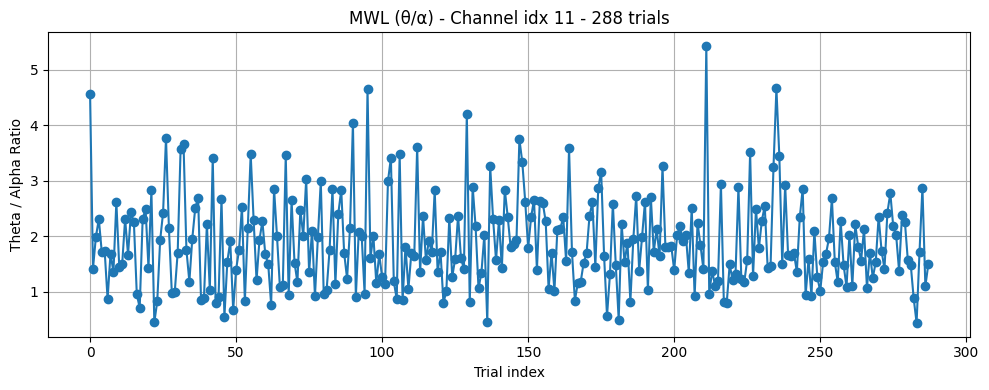

CSV salvato in: /Users/giuseppebonomo/Desktop/RatioWaveNet/BCI2a_IV/mental_work_load/A5/mwl_results_A5.csv


In [2]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import welch
import csv

def load_BCI2a_data(data_path, subject, training=False, all_trials=True):
    """
    Carica i dati BCI Competition IV-2a da .mat (BNCI Horizon 001-2014).
    Restituisce:
      - data_return: array [n_trials, n_channels, window_Length]
      - class_return: array [n_trials] (etichette 0-3)
    """
    # Parametri
    n_channels    = 22
    n_tests       = 6 * 48       # max trial count
    fs            = 250
    window_Length = 7 * fs       # 7 secondi
    t1 = int(1.5 * fs)           # inizio finestra MI
    t2 = int(6.0 * fs)           # fine finestra MI

    # Preallocazione
    data_return  = np.zeros((n_tests, n_channels, window_Length))
    class_return = np.zeros(n_tests, dtype=int)
    valid_count  = 0

    # Carica .mat
    fname = f"A0{subject}E.mat"
    mat   = sio.loadmat(os.path.join(data_path, fname), struct_as_record=False, squeeze_me=True)
    a_data = mat['data']  # struct MATLAB 1×N

    # Itera sui record (anche se singolo)
    for rec in np.atleast_1d(a_data):
        # Estrai campi e normalizza shape
        X         = np.array(rec.X)           # [samples_tot × 22]
        trial_on  = np.array(rec.trial).flatten()     # onset samples
        labels    = np.array(rec.y).flatten()         # 1–4
        artifacts = np.array(rec.artifacts).flatten() # 0=clean,1=artifact

        # Per ogni trial estrai la finestra di 7s
        for i in range(trial_on.shape[0]):
            if artifacts[i] != 0 and not all_trials:
                continue
            start = int(trial_on[i])
            segment = X[start:start + window_Length, :n_channels].T
            data_return[valid_count]  = segment
            class_return[valid_count] = int(labels[i]) - 1  # 0-based
            valid_count += 1

    # Ritaglia al numero di trial validi e alla finestra MI desiderata
    data_return  = data_return[:valid_count, :, t1:t2]
    class_return = class_return[:valid_count]

    return data_return, class_return

def analyze_mwl(data, labels,
                fs=250,
                channel_idx=11,
                theta_band=(4,7),
                alpha_band=(8,12),
                output_csv='mwl_results.csv'):
    """
    Calcola e plotta il rapporto theta/alpha per ogni trial su channel_idx.
    Salva i risultati in CSV se output_csv non è stringa vuota.
    """
    n_trials = data.shape[0]
    ratios   = []

    # Calcolo theta/alpha per ciascun trial
    for ti in range(n_trials):
        sig = data[ti, channel_idx, :]
        f, Pxx = welch(sig, fs=fs, nperseg=fs*2)
        theta = np.trapz(Pxx[(f>=theta_band[0]) & (f<=theta_band[1])],
                         f[(f>=theta_band[0]) & (f<=theta_band[1])])
        alpha = np.trapz(Pxx[(f>=alpha_band[0]) & (f<=alpha_band[1])],
                         f[(f>=alpha_band[0]) & (f<=alpha_band[1])])
        ratios.append(theta / (alpha + 1e-6))

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(ratios, marker='o')
    plt.title(f"MWL (θ/α) - Channel idx {channel_idx} - {n_trials} trials")
    plt.xlabel("Trial index")
    plt.ylabel("Theta / Alpha Ratio")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Export CSV
    if output_csv:
        with open(output_csv, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['trial','label','theta_alpha','channel_idx'])
            for i, r in enumerate(ratios, start=1):
                writer.writerow([i, labels[i-1], r, channel_idx])
        print(f"CSV salvato in: {os.path.abspath(output_csv)}")

if __name__ == "__main__":
    # ==== CONFIGURAZIONE ====
    data_path   = '/Users/giuseppebonomo/Desktop/RatioWaveNet/BCI2a_IV/dataset/s5/'   # cartella con A01T.mat
    subject     = 5              # [1..9]
    training    = False           # True=sessione T (training), False=E (testing)
    all_trials  = True           # True=includi anche trials con artifact
    channel_idx = 11             # indice elettrodo (0-based, 11≈Cz)
    output_csv  = 'mwl_results_A5.csv'
    # =======================

    # 1) Carica i dati
    X, y = load_BCI2a_data(data_path, subject, training, all_trials)
    # 2) Calcola e visualizza MWL
    analyze_mwl(X, y,
                fs=250,
                channel_idx=channel_idx,
                theta_band=(4,7),
                alpha_band=(8,12),
                output_csv=output_csv)


Dati combinati salvati in 'combined_results.csv'
Grafico combinato salvato in 'subject5_combined_plot.png'


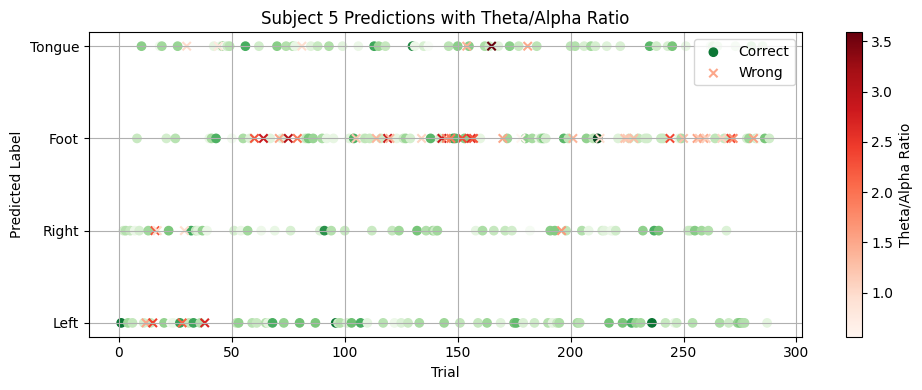

In [3]:
#combino i dati di che ho ottenuto in subject1_results.csv e mwl_results_A5.csv
import pandas as pd
df1 = pd.read_csv('subject5_results.csv')
df2 = pd.read_csv('mwl_results_A5.csv')
combined_df = pd.merge(df1, df2, on='trial', suffixes=('_subject1', '_mwl'))
combined_df.to_csv('combined_results.csv', index=False)
print("Dati combinati salvati in 'combined_results.csv'")

# Ora facciamo un plot come quello di prima per i dati combinati ovvero colori diversi per le predizioni corrette e sbagliate, però tenendo in considerazione ratio theta/alpha
import matplotlib.pyplot as plt
correct = combined_df['true_label'] == combined_df['pred_label']
trials  = combined_df['trial']
preds   = combined_df['pred_label']
ratios  = combined_df['theta_alpha']
plt.figure(figsize=(10, 4))
plt.scatter(trials[correct],   preds[correct],
            c=ratios[correct], cmap='Greens', marker='o', label='Correct')
plt.scatter(trials[~correct],  preds[~correct],
            c=ratios[~correct], cmap='Reds', marker='x', label='Wrong')
plt.title("Subject 5 Predictions with Theta/Alpha Ratio")
plt.xlabel('Trial')
plt.ylabel('Predicted Label')
plt.yticks([0,1,2,3], ['Left','Right','Foot','Tongue'])
plt.colorbar(label='Theta/Alpha Ratio')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.savefig('subject5_combined_plot.png')
print("Grafico combinato salvato in 'subject5_combined_plot.png'")

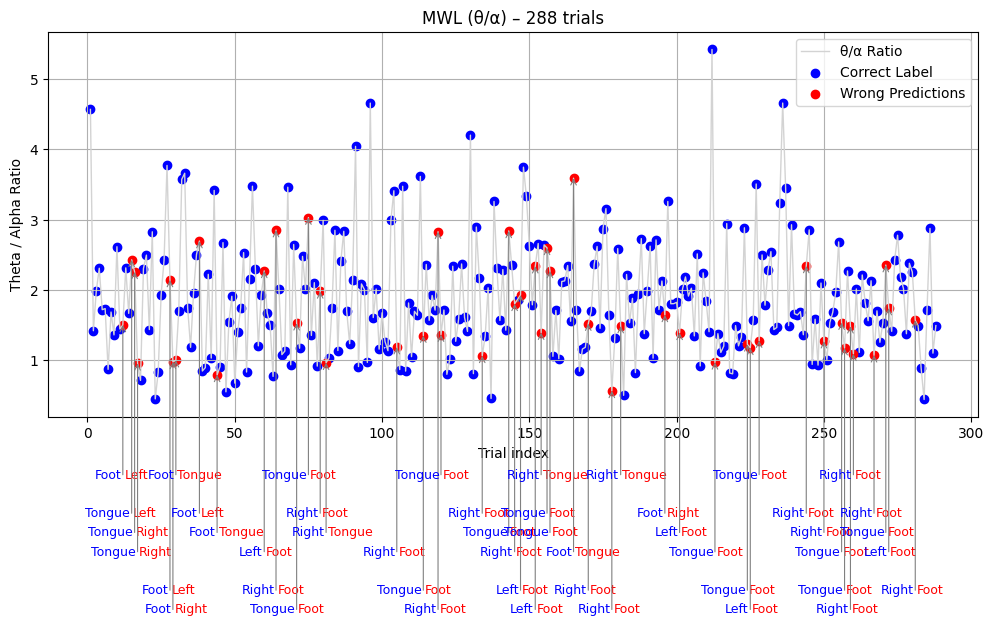

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Dati dal DataFrame combined_df
trials = combined_df['trial'].values
ratios = combined_df['theta_alpha'].values
true   = combined_df['true_label'].values
preds  = combined_df['pred_label'].values

# Filtra solo gli errori
wrong_mask   = preds != true
wrong_trials = trials[wrong_mask]
wrong_ratios = ratios[wrong_mask]
true_wrong   = true[wrong_mask]
pred_wrong   = preds[wrong_mask]

class_names = {0:'Left', 1:'Right', 2:'Foot', 3:'Tongue'}
n_trials    = trials.max()

fig, ax = plt.subplots(figsize=(12, 5))

# 1) Traccia θ/α e scatter
ax.plot(trials, ratios, color='lightgray', linewidth=1, label='θ/α Ratio')
ax.scatter(trials[~wrong_mask], ratios[~wrong_mask],
           c='blue', marker='o', label='Correct Label')
ax.scatter(wrong_trials, wrong_ratios,
           c='red',  marker='o', label='Wrong Predictions')

# 2) Prepara i livelli di offset (in axes-fraction)
cycle = [1, 2, 3, 4,5,6]
levels = {
    1: -0.15,  # 5% sotto il minimo
    2: -0.25,  # 12%
    3: -0.30,  # 19%
    4: -0.35,  # 26%
    5: -0.45,  # 33%
    6: -0.50   # 40%
}

# Limiti y per calcolare coordinate in data
ymin, ymax = ax.get_ylim()
yrsange = ymax - ymin

# 3) Loop sugli errori
for idx, (t, r, tr_lbl, pr_lbl) in enumerate(zip(
        wrong_trials, wrong_ratios, true_wrong, pred_wrong)):
    lvl = cycle[idx % len(cycle)]
    # y_frac in axes fraction, poi in data coords
    y_frac = levels[lvl]
    y_text = ymin + y_frac * yrsange

    # Freccia verticale (annotate da y_text fino a r)
    ax.annotate(
        '',
        xy=(t, r),               # fine freccia (punto dati)
        xytext=(t, y_text),      # inizio freccia (testo)
        xycoords='data',
        textcoords='data',
        arrowprops=dict(
            arrowstyle='->',
            color='gray',
            lw=0.8,
            shrinkA=0,
            shrinkB=0,
        )
    )

    # True label (blu) a sinistra
    ax.text(
        t - 0.5, y_text,         # 0.5 trial a sinistra
        class_names[tr_lbl],
        color='blue',
        fontsize=9,
        ha='right', va='center'
    )
    # Pred label (rosso) a destra
    ax.text(
        t + 0.5, y_text, 
        class_names[pr_lbl],
        color='red',
        fontsize=9,
        ha='left', va='center'
    )

# 4) Rifiniture
ax.set_title(f"MWL (θ/α) – {n_trials} trials")
ax.set_xlabel("Trial index")
ax.set_ylabel("Theta / Alpha Ratio")
ax.legend(loc='upper right')
ax.grid(True)
#plt.subplots_adjust(bottom=0.1)  # spazio per le etichette sotto
plt.show()
